# HW3 - Prediction

In [1]:
# Librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

In [2]:
# Load Data
train_df = pd.read_csv('/Users/alizeearchereau/Desktop/ALIZEE/1- EDHEC/5-M2 (MSc)/8--Data Mining/HW3 - Prediction/health_train.csv')
test_df = pd.read_csv('/Users/alizeearchereau/Desktop/ALIZEE/1- EDHEC/5-M2 (MSc)/8--Data Mining/HW3 - Prediction/health_test_features.csv')

# Separate Target and Features
X = train_df.drop('Annual_Premium', axis=1)     # features
Y = train_df['Annual_Premium']                  # target

# Check what the data looks like
print("Training data shape:", X.shape)
X.head()

Training data shape: (1070, 6)


,Age_Years,Gender,Body_Mass_Index,Dependents,Tobacco_User,Residential_Area
0,46,F,19.95,2,N,Rural_A
1,47,F,24.32,0,N,Rural_B
2,52,F,24.86,0,N,Metro_B
3,39,F,34.32,5,N,Metro_B
4,54,F,21.47,3,N,Rural_A


# 1. Preprocessing

1st problem: imputing if there are missing values

In [3]:
print(train_df.isnull().sum())
print(test_df.isnull().sum())

Age_Years           0
Gender              0
Body_Mass_Index     0
Dependents          0
Tobacco_User        0
Residential_Area    0
Annual_Premium      0
dtype: int64
Age_Years           0
Gender              0
Body_Mass_Index     0
Dependents          0
Tobacco_User        0
Residential_Area    0
dtype: int64


2nd problem: creating dummy variables for categorical string data:  
Gender has 2 categories, Tobacco User has 2 categories, Residential Area has 4 categories.

In [4]:
# We must create the dummy columns also on the test data. we do both at the same time to make sure we create the same columns
features_train_and_test = pd.concat([X, test_df], axis=0)

# Convert categorical variables into dummy/indicator variables
features_train_and_test_encoded = pd.get_dummies(features_train_and_test, drop_first=True)    # drop_first=True is what ensures we create K-1 columns for K categories

# Separate them back into Train and Test
X_encoded = features_train_and_test_encoded.iloc[:len(train_df)]        # rows at the start
X_test_encoded = features_train_and_test_encoded.iloc[len(train_df):]   # rows at the end

print("Data shape after encoding:", X_encoded.shape)
X_encoded.head()

Data shape after encoding: (1070, 8)


,Age_Years,Body_Mass_Index,Dependents,Gender_M,Tobacco_User_Y,Residential_Area_Metro_B,Residential_Area_Rural_A,Residential_Area_Rural_B
0,46,19.95,2,False,False,False,True,False
1,47,24.32,0,False,False,False,False,True
2,52,24.86,0,False,False,True,False,False
3,39,34.32,5,False,False,True,False,False
4,54,21.47,3,False,False,False,True,False


# 2.a - OLS

We try first with OLS. 
For validation, a single split is risky (the test set might be randomly too easy to predict, or too hard). We use K-Fold cross-validation to ensure that each data point is used for validation exactly once.

We wrap it in a function.

In [5]:
# Cross-validation with 10 splits (standard choice)
folds = KFold(n_splits=10, shuffle=True, random_state=42)


def evaluate_linear_model(model, name, X_input):

    # Calc the - MSE and -MAE scores (cf in [14] de correction de TD))
    neg_mse = cross_val_score(model, X_input, Y, scoring='neg_mean_squared_error', cv=folds)
    neg_mae = cross_val_score(model, X_input, Y, scoring='neg_mean_absolute_error', cv=folds)

    # Convert to RMSE and MAE
    rmse_scores = np.sqrt(-neg_mse)
    avg_rmse = np.mean(rmse_scores)
    avg_mae = np.mean(-neg_mae)
    
    print(f"[{name} model] Average RMSE: {avg_rmse:.2f} | Average MAE: {avg_mae:.2f}")
    return avg_rmse


# Model 1: OLS 
rmse_ols = evaluate_linear_model(LinearRegression(), "OLS", X_encoded)



[OLS model] Average RMSE: 7035.74 | Average MAE: 4871.81


We visualize our lin model to see if we missed anything & confronter Fit / Actual

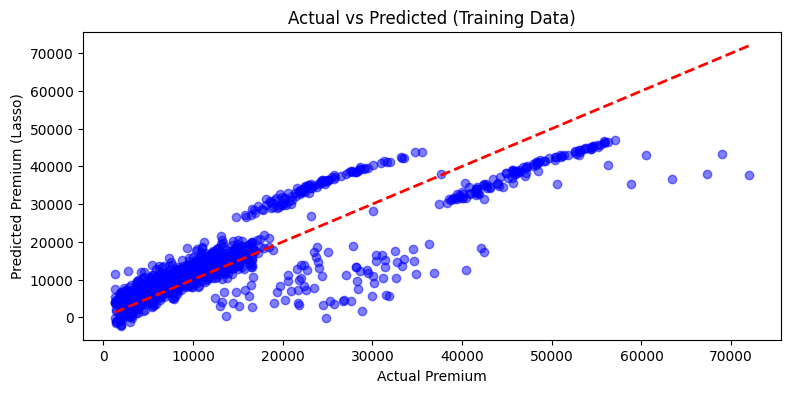

<Figure size 640x480 with 0 Axes>

[OLS model] Average RMSE: 7035.74 | Average MAE: 4871.81


In [ ]:
# Visualize OLS fit/actual 
model=LinearRegression().fit(X_encoded, Y)             # fit
Y_pred_OLS = model.predict(X_encoded)                  # predict Y (of training data)


# Plot predicted value against actual values
plt.figure(figsize=(9, 4))
plt.scatter(Y, Y_pred_OLS, alpha=0.5, color='blue')
plt.plot([Y.min(), Y.max()], [Y.min(), Y.max()], 'r--', lw=2) # Perfect fit line Y=Y_pred
plt.xlabel('Actual Premium')
plt.ylabel('Predicted Premium (OLS)')
plt.title('Actual vs Predicted (Training Data)')
plt.show()
    
plt.tight_layout()
plt.show()


rmse_ols_log=evaluate_linear_model(LinearRegression(), "OLS", X_encoded)

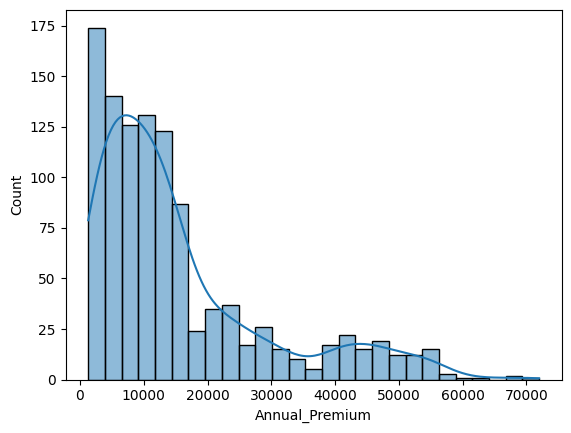

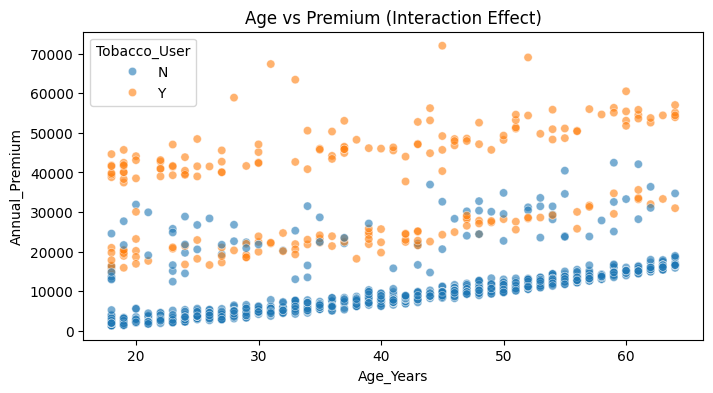

In [7]:
# Plot Premium distribution
sns.histplot(Y, kde=True)

# 3. Age vs Premium colored by Smoking
plt.figure(figsize=(8, 4))
sns.scatterplot(x='Age_Years', y='Annual_Premium', hue='Tobacco_User', data=train_df, alpha=0.6)
plt.title('Age vs Premium (Interaction Effect)')
plt.show()

We see 2 things:  
- Insurance premiums distribution is right-skewed (lots of low prices, a few huge ones). We should try predicting log(Annual_Premium).  
- As it is expectable, we see there are most likely interaction terms to take into account, like Smoker x BMI or Smoker x Age: this is common in insurance.  

However, OLS does not handle the multicollinearity brought by having both Smoker AND its interaction columns in the features. It is safer to use Ridge/Lasso to integrate them.  
Ridge: Will handle the correlation and distribute the weights appropriately.  
Lasso: Will pick the strongest predictor (e.g., keep AxB and kill A) if the interaction explains the variance better than the main effect alone.  

We will thus use these findings in Ridge/Lasso models and try to minimize RMSE.  

# 2.b Lasso/Ridge

We want to try Lasso/ridge predictions.

However, we have to scale data, otherwise the penalty term will unfairly punish variables with larger scales (eg Age) compared to small dummy variables (0 or 1) when we use Lasso/Ridge.  
Because we are using cross-validation, the scaling has to be re-done at each step! Otherwise it would be leakage.  

Do do this we can use a pipeline (and cross_eval_score would still work), or do it manually.  
We will write a new function to do it manually (and regret it later) 

In [8]:
# Create another dataset for feature egineering 
X_eng = X_encoded.copy()
X_eng['Smoker_BMI'] = X_eng['Tobacco_User_Y'] * X_eng['Body_Mass_Index']
X_eng['Smoker_Age'] = X_eng['Tobacco_User_Y'] * X_eng['Age_Years']

# Log transfo of target
Y_log = np.log1p(Y)

# New evaluation function (Scaling + log and interaction terms)
def evaluate_log_scale_inter(model, name, X, Y_raw, Y_transformed):
    rmse_list = []
    mae_list=[]
    
    # We iterate through the folds
    for train_idx, val_idx in folds.split(X, Y_raw):            # For each fold, 1 list of indexes to take for trainig and 1 list of indexes for testing 
        # split data (train/set for this fold)
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        Y_train_log = Y_transformed.iloc[train_idx] # train on LOG
        Y_val_raw = Y_raw.iloc[val_idx]             # we will validate on DOLLAR
        
        # scale INSIDE the fold (Fit on Train, Transform Validation)
        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)   # fit on Train + apply
        X_val_s = scaler.transform(X_val)           # apply on Val
        
        # fit model, apply to predict
        model.fit(X_train_s, Y_train_log)
        pred_log = model.predict(X_val_s)
        
        # renverse Transform (Log -> Dollar)
        pred_dollar = np.expm1(pred_log)
    

        rmse = np.sqrt(mean_squared_error(Y_val_raw, pred_dollar))  # NB SCORE MUST BE DONE ON un-SCALED 
        rmse_list.append(rmse)
        mae = mean_absolute_error(Y_val_raw, pred_dollar)
        mae_list.append(mae)

    # Scores
    avg_rmse = np.mean(rmse_list)
    avg_mae = np.mean(mae_list)
    print(f"[{name}] Average RMSE: {avg_rmse:.2f} | Average MAE: {avg_mae:.2f}")
    return avg_rmse




We now use that function for different values of alpha (=strength of penalty) for Ridge and Lasso.

In [9]:
# Model 2: Ridge
for alpha in [0.01, 1, 5.0, 6.0,7, 10.0, 11, 50.0]:
    evaluate_log_scale_inter(Ridge(alpha=alpha), f"Ridge a={alpha}", X_eng, Y, Y_log)

print("")

# Model 3: Lasso
# Lasso performs feature selection
for alpha in [0.0001, 0.0005, 0.001, 0.002, 0.003, 0.005, 0.1, 1.0]:       # "Alpha for Lasso on Log targets is usually 0.001 to 100"
    evaluate_log_scale_inter(Lasso(alpha=alpha, max_iter=10000), f"Lasso a={alpha}", X_eng, Y, Y_log)

[Ridge a=0.01] Average RMSE: 6459.51 | Average MAE: 3349.56
[Ridge a=1] Average RMSE: 6447.45 | Average MAE: 3341.25
[Ridge a=5.0] Average RMSE: 6422.96 | Average MAE: 3317.21
[Ridge a=6.0] Average RMSE: 6421.89 | Average MAE: 3313.74
[Ridge a=7] Average RMSE: 6422.49 | Average MAE: 3311.51
[Ridge a=10.0] Average RMSE: 6432.92 | Average MAE: 3308.26
[Ridge a=11] Average RMSE: 6438.85 | Average MAE: 3308.02
[Ridge a=50.0] Average RMSE: 6966.88 | Average MAE: 3550.05

[Lasso a=0.0001] Average RMSE: 6455.72 | Average MAE: 3347.18
[Lasso a=0.0005] Average RMSE: 6448.53 | Average MAE: 3337.52
[Lasso a=0.001] Average RMSE: 6441.39 | Average MAE: 3326.81
[Lasso a=0.002] Average RMSE: 6433.55 | Average MAE: 3307.42
[Lasso a=0.003] Average RMSE: 6432.09 | Average MAE: 3289.51
[Lasso a=0.005] Average RMSE: 6452.06 | Average MAE: 3264.01
[Lasso a=0.1] Average RMSE: 7474.62 | Average MAE: 4057.67
[Lasso a=1.0] Average RMSE: 14623.50 | Average MAE: 9544.45


Ridge's min RMSE is around 6421.  
Lasso's min RMSE is around 6432.  

Ridge/Lasso perform better than OLS, so we can say that OLS was overfitting.  
Here Ridge seems to perform the best.
It makes sense because since we created columns that are correlated, Lasso will pick one and push the other to 0. However, Ridge will collectively shrink them (eg Smoking is bad, BMI is bad, and the combination is extra bad).  

Right now, our best model is Ridge. The optimal alpha is $\alpha=6$ (or rather close to it) to minimize MAE and RMSE. We store this model and its evaluation score.

In [10]:
best_ridge = Ridge(alpha=6)

rmse_ridge = evaluate_log_scale_inter(best_ridge, f"Ridge a={alpha}", X_eng, Y, Y_log)

[Ridge a=1.0] Average RMSE: 6421.89 | Average MAE: 3313.74


We want to visualize the prediction of the training data to see if we missed anything: what features are represented? What does the prediction look like against actual?  
As we did inside each step inside the function, we will have to scale the feature data and logtransform the target before applying the model, and un-transform the target.

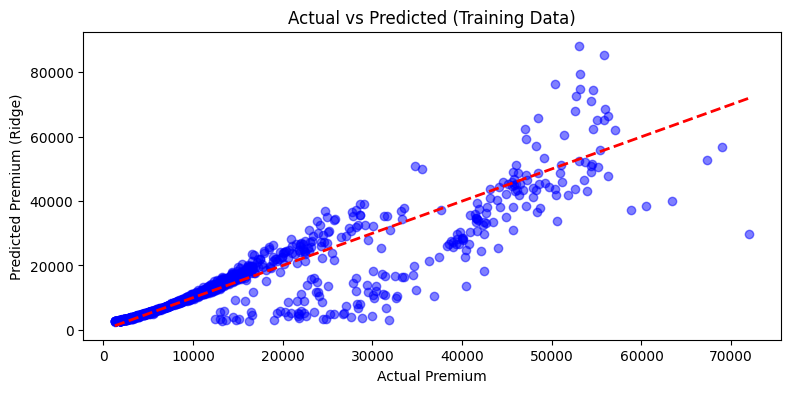

/var/folders/4w/5xh4p2d91wdc6mw9hknkhmgm0000gn/T/ipykernel_81446/2236190741.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette=couleurs)


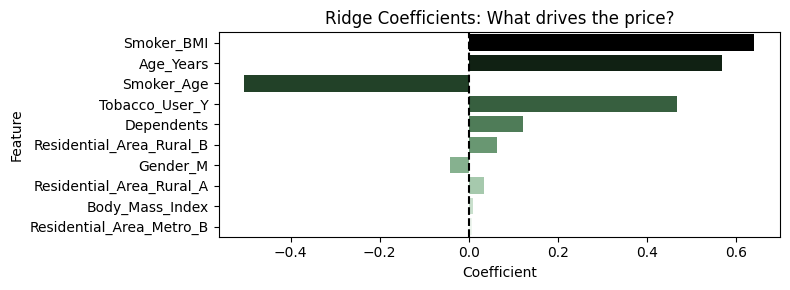

In [11]:
# Using the engineered data, NOT X_encoded. 
scaler = StandardScaler()
X_eng_scaled = scaler.fit_transform(X_eng) 
X_eng_scaled_df = pd.DataFrame(X_eng_scaled, columns=X_eng.columns)

# Fit model, predict
best_ridge.fit(X_eng_scaled_df, Y_log)                 # fit
Y_pred_log = best_ridge.predict(X_eng_scaled_df)       # predict logY (of training data)

# Renverse Transform (Log -> Dollar)
Y_pred_log_unlog = np.expm1(Y_pred_log)


# Plot predicted value against actual values
plt.figure(figsize=(9, 4))
plt.scatter(Y, Y_pred_log_unlog, alpha=0.5, color='blue')
plt.plot([Y.min(), Y.max()], [Y.min(), Y.max()], 'r--', lw=2) # Perfect fit line Y=Y_pred
plt.xlabel('Actual Premium')
plt.ylabel('Predicted Premium (Ridge)')
plt.title('Actual vs Predicted (Training Data)')
plt.show()


# Plot coefficients     # Plotted with genAI help
# Beta coefficients show the strength of the linear relationship. Ridge pushes some to 0 ("feature selection").
coef_df = pd.DataFrame({
    'Feature': X_eng_scaled_df.columns,
    'Coefficient': best_ridge.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

plt.figure(figsize=(8, 3))
couleurs=sns.cubehelix_palette(start=2, rot=0, dark=0, light=.95, reverse=True, n_colors=len(coef_df))      # vert to black
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette=couleurs)
plt.title('Ridge Coefficients: What drives the price?')
plt.axvline(0, color='black', linestyle='--')

    
plt.tight_layout()
plt.show()

On the Actual vs Predicted plot, we still identify several clusters in the medium range of Actual Premium.  
Our interaction terms and log transformation were not enough and the plot is not really satisfactory..   

Note: i was vvvery doubtful with the negative coefficient for Age x Smoker, but it was explained by gpt: "The negative coefficient means that Age drives the price less aggressively for smokers than for non-smokers (relative to the base price). The net effect of Smoking (coeff all interaction terms - coeff AgexSmoker) is still positive. Older smokers do pay more than younger smokers."

Anyway, to do better, we can use tree-based ML models. This will be way more precise to capture the intereaction between each variable by a function that is not necessary monotone.  

# 2.c Doing better

We are going to try to find a better prediction for our training data using other models.  

Tree-based models don't need scaling, so we don't have to worry about in-fold scaling in the function. We can go back to before anything was fitted or transformed: use X_encoded.

In [12]:
# Libraries for those ML models
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# We rebuild our function and adapt it to tree models
def evaluate_tree_model(model, name):
    # Getting RMSE score and avg
    neg_mse = cross_val_score(model, X_encoded, Y, scoring='neg_mean_squared_error', cv=folds)  # We still use CV and with the same 'folds' defined earlier
    rmse_scores = np.sqrt(-neg_mse)
    avg_rmse = np.mean(rmse_scores)
    
    print(f"[{name} model] Average RMSE: {avg_rmse:.2f}")
    return avg_rmse

# Model 4: Random Forest (ML Part 2.6 = Bagging)
# "Reduces variance, good for handling the non-linear interaction."
rf_model = RandomForestRegressor(random_state=42)
rmse_rf = evaluate_tree_model(rf_model, "Random Forest")

# Model 5: Gradient Boosting (ML Part 2.6 = Boosting)
# "Reduces bias. Often provides the best accuracy.
gb_model = GradientBoostingRegressor(random_state=42)
rmse_gb = evaluate_tree_model(gb_model, "Gradient Boosting")

[Random Forest model] Average RMSE: 5648.15
[Gradient Boosting model] Average RMSE: 5300.38


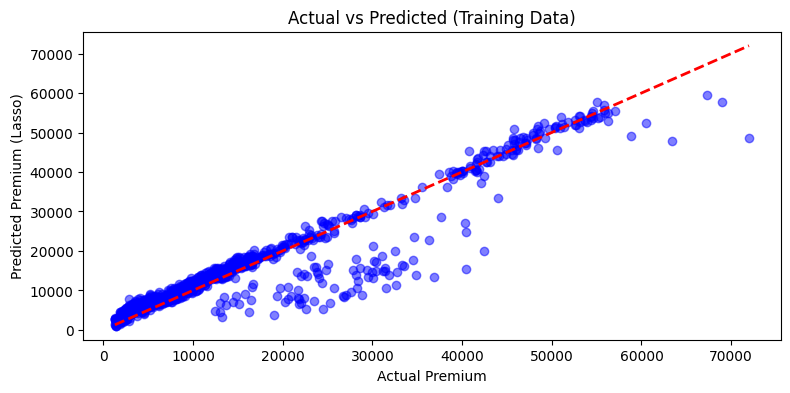

<Figure size 640x480 with 0 Axes>

In [ ]:
# Plot predicted value against actual values of the training data

test = GradientBoostingRegressor(n_estimators=100, random_state=42)
# 2. Fit on the FULL training data (X_encoded)
test.fit(X_encoded, Y)

# Use on the data X_encoded itself
train_predictions = test.predict(X_encoded)


plt.figure(figsize=(9, 4))
plt.scatter(Y, train_predictions, alpha=0.5, color='blue')
plt.plot([Y.min(), Y.max()], [Y.min(), Y.max()], 'r--', lw=2) # Perfect fit line Y=Y_pred
plt.xlabel('Actual Premium')
plt.ylabel('Predicted Premium (Gradient Boosting)')
plt.title('Actual vs Predicted (Training Data)')
plt.show()
    
plt.tight_layout()
plt.show()

Tree-based model have a lower RMSE mean.
The best prediction model is the one using Gradient Boosting.

We will chose this one for our predictions on the test dataset.  

**Thoughts**  
- Rq: we could have gone even further and done Hyperparameter tuning for number of treees, depth, learning rate, but I've spent enough time on this.. Time-ROI tradeoff!  

The default parameters of GB are  
"n_estimators=100: Number of trees in the forest. Enough trees to learn complex patterns, but usually not enough to massively overfit on medium-sized data.  
max_depth=3: Shallow trees prevent the model from memorizing noise (overfitting), forcing it to learn general trends.  
learning_rate=0.1: A safe middle ground"  

- Rq2: I didn't use a pipeline and I probably should have, it woudl have been way easier & safer
- Rq3: could have tested log(Premium) predictions with ML models.  
- Rq4: quid de significance des param dans OLS?

# 3. Predictions on the test set

In [13]:

final_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
# 2. Fit on the FULL training data (X_encoded)
final_model.fit(X_encoded, Y)

# Use on the prepared test data X_test_encoded (ie the one with dummy vars) to predict
final_predictions = final_model.predict(X_test_encoded)

# Export

In [14]:
# Export predictions 
df_to_submit = pd.DataFrame(final_predictions, columns=['Annual_Premium'])
df_to_submit.to_csv('/Users/alizeearchereau/Desktop/ALIZEE/1- EDHEC/5-M2 (MSc)/8--Data Mining/HW3 - Prediction/predictions.csv', header=False, index=False)
print(df_to_submit.head())

   Annual_Premium
0    12575.647333
1     6609.981582
2    32746.130588
3    11148.464908
4    38564.816232
